In [2]:
import pickle
import numpy as np
import pandas as pd
import os
from copy import deepcopy
from pathlib import Path
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.animation

import sys
sys.path.append('../')

import pypolo2

# Environment -- PINNS

In [3]:
Setting = pypolo2.utilities.Config()
strategy_name = ["EffectOrientedSelectiveSpray",
                 "EffectOrientedMCTSSpray",
                 "MaximumCoverageSpray",
                "NonmyonicLatticeSpray",
                "TRACT",
                "Traffic_jam",
                 "NoSpray"]
comparing_variables = [["teamsize_1","teamsize_2","teamsize_3","teamsize_4","teamsize_5"],
                       ["numsource_1","numsource_2","numsource_3","numsource_4","numsource_5"]]
seeds = [7,11,18,20,25,36,42,50,60,72,80,85]
team_sizes = [1,2,3,4,5]
sourcenums = [1,2,3,4,5]

# Average Suppression

In [5]:
# 累计pm2.5控制总量,所有实验的平均值
strategy_sumsprayeffect = []
sche_step = 0
adaptive_step = 0
# teamsize
for strategy in strategy_name:
    if strategy == "EffectOrientedMCTSSpray":
        sche_step = 8
        adaptive_step = 8
    elif strategy == "NonmyonicLatticeSpray":
        sche_step = 18
        adaptive_step = 4
    elif strategy == "Traffic_jam":
        sche_step = 18
        adaptive_step = 3
    elif strategy == "TRACT":
        sche_step = 18
        adaptive_step = 3
    else:
        sche_step = 18
        adaptive_step = 3
    variable_sumsprayeffect = []
    for i in range(5):
        comparing_variable = comparing_variables[0][i]
        team_size = team_sizes[i]
        sourcenum = 3
        seed_sumsprayeffect = []
        for seed in seeds:
            pklname = f'SEED_{seed}_X{Setting.grid_x}_Y{Setting.grid_y}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}'
            pkldir = './outputs/' + strategy + '/' + comparing_variable + '/' + pklname + ".pkl"
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            seed_sumsprayeffect.append(np.sum(data['spray_effect'])/400/48)
        variable_sumsprayeffect.append(np.mean(seed_sumsprayeffect))
        
    # numsource
    for i in range(5):
        comparing_variable = comparing_variables[1][i]
        team_size = 3
        sourcenum = sourcenums[i]
        seed_sumsprayeffect = []
        for seed in seeds:
            pklname = f'SEED_{seed}_X{Setting.grid_x}_Y{Setting.grid_y}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}'
            pkldir = './outputs/' + strategy + '/' + comparing_variable + '/' + pklname + ".pkl"
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            seed_sumsprayeffect.append(np.sum(data['spray_effect'])/48/400)
        variable_sumsprayeffect.append(np.mean(seed_sumsprayeffect))
        
    strategy_sumsprayeffect.append(np.mean(variable_sumsprayeffect))
print(strategy_sumsprayeffect)

[3.2630437755638786, 2.86185365055276, 2.3471333489390647, 2.7647542515137085, 3.048703683398404, 3.130152617958029, 1.796752554964969e-05]


# Average Pollution Concentration

In [4]:
# 区域平均pm2.5浓度,所有实验的平均值
strategy_meanpollution = []
# teamsize
sche_step = 0
adaptive_step = 0
for strategy in strategy_name:
    if strategy == "EffectOrientedMCTSSpray":
        sche_step = 8
        adaptive_step = 8
    elif strategy == "NonmyonicLatticeSpray":
        sche_step = 18
        adaptive_step = 4
    elif strategy == "Traffic_jam":
        sche_step = 18
        adaptive_step = 3
    elif strategy == "TRACT":
        sche_step = 18
        adaptive_step = 3
    else:
        sche_step = 18
        adaptive_step = 3
    variable_meanpollution = []
    for i in range(5):
        comparing_variable = comparing_variables[0][i]
        team_size = team_sizes[i]
        sourcenum = 3
        seed_meanpollution = []
        for seed in seeds:
            pklname = f'SEED_{seed}_X{Setting.grid_x}_Y{Setting.grid_y}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}'
            pkldir = './outputs/' + strategy + '/' + comparing_variable + '/' + pklname + ".pkl"
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            time_meanpollution = []
            for i in range(48):
                if i >= 24:
                    mean_env = np.mean(data['truth_env'][i])
                    time_meanpollution.append(mean_env)
            seed_meanpollution.append(np.mean(time_meanpollution))
        variable_meanpollution.append(np.mean(seed_meanpollution))
        
    # numsource
    for i in range(5):
        comparing_variable = comparing_variables[1][i]
        team_size = 3
        sourcenum = sourcenums[i]
        seed_sumsprayeffect = []
        for seed in seeds:
            pklname = f'SEED_{seed}_X{Setting.grid_x}_Y{Setting.grid_y}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}'
            pkldir = './outputs/' + strategy + '/' + comparing_variable + '/' + pklname + ".pkl"
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            for i in range(48):
                if i >= 24:
                    mean_env = np.mean(data['truth_env'][i])
                    time_meanpollution.append(mean_env)
            seed_meanpollution.append(np.mean(time_meanpollution))
        variable_meanpollution.append(np.mean(seed_meanpollution))
        
    strategy_meanpollution.append(np.mean(variable_meanpollution))
print(strategy_meanpollution)

[33.077575577111624, 40.832835731388926, 47.19795367316438, 42.04805788559145, 34.61786355834077, 34.341655572817146, 94.22033446807441]


In [5]:
current_dir = os.getcwd()
# 计算标准差。标准误
# 首先生成样本列表
data_process = {}
for strategy in strategy_name:
    # 参数配置
    if strategy == "EffectOrientedMCTSSpray":
        sche_step = 8
        adaptive_step = 8
    elif strategy == "NonmyonicLatticeSpray":
        sche_step = 18
        adaptive_step = 4
    elif strategy == "Traffic_jam":
        sche_step = 18
        adaptive_step = 3
    elif strategy == "TRACT":
        sche_step = 18
        adaptive_step = 3
    else:
        sche_step = 18
        adaptive_step = 3
    seed_meanpollution = []
    for seed in seeds:
        variable_meanpollution = []
        # team_size
        for i in range(5):
            comparing_variable = comparing_variables[0][i]
            team_size = team_sizes[i]
            sourcenum = 3
            pklname = f'SEED_{seed}_X{Setting.grid_x}_Y{Setting.grid_y}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}'
            pkldir = './outputs/' + strategy + '/' + comparing_variable + '/' + pklname + ".pkl"
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            time_meanpollution = []
            for i in range(48):
                if i >= 24:
                    mean_env = np.mean(data['truth_env'][i])
                    time_meanpollution.append(mean_env)
            variable_meanpollution.append(np.mean(time_meanpollution))
        # numsource
        for i in range(5):
            comparing_variable = comparing_variables[1][i]
            team_size = 3
            sourcenum = sourcenums[i]
            pklname = f'SEED_{seed}_X{Setting.grid_x}_Y{Setting.grid_y}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}'
            pkldir = './outputs/' + strategy + '/' + comparing_variable + '/' + pklname + ".pkl"
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            for i in range(48):
                if i >= 24:
                    mean_env = np.mean(data['truth_env'][i])
                    time_meanpollution.append(mean_env)
            variable_meanpollution.append(np.mean(time_meanpollution))
        seed_meanpollution.append(np.mean(variable_meanpollution))

    data_process[strategy] = seed_meanpollution
print(data_process)

{'EffectOrientedSelectiveSpray': [32.08659271362751, 40.79542557809096, 37.96522611300242, 32.742372592147085, 36.52599206655141, 25.63226422387138, 37.77882400142143, 32.066023875547145, 25.440172759501774, 39.80337949229899, 38.94899451754695, 35.744076513674585], 'EffectOrientedMCTSSpray': [46.621283239334396, 49.594722143341556, 48.63782688311387, 40.64180455227812, 50.031111333727424, 29.45017335917072, 39.25190801644603, 40.90012953566098, 31.353046439342364, 44.59620369721181, 54.46549228226836, 37.99602365603928], 'MaximumCoverageSpray': [46.12018323164752, 48.657201732307804, 49.068366400784875, 50.49752056419576, 49.62363875492496, 58.664140580024295, 50.596670778102165, 49.980257721771856, 42.524182974610966, 51.46358293904693, 50.846558787482365, 50.91031083588202], 'NonmyonicLatticeSpray': [42.0849378419609, 45.613008604676, 47.06273016584316, 44.20268219723407, 50.48899181514408, 34.53074468649008, 44.59368008648626, 48.259919003708106, 32.06971349708461, 45.6584338288102

In [6]:
import plotly.graph_objects as go
import numpy as np

width = 1000
height = 666
colors_dict = ['#3D9182','#C74223','#245C8F', '#FF8C00']

xtitle = 'Sprinkle Strategy'
ytitle = 'Average Suppression of PM2.5(μg/m³)'
# 创建箱线图
fig = go.Figure()

# 按原始顺序添加箱线图
strategies = ['NoSpray', 'MaximumCoverageSpray', 'EffectOrientedMCTSSpray', 'NonmyonicLatticeSpray', 'EffectOrientedSelectiveSpray']
for idx, strategy in enumerate(strategies):
    fig.add_trace(go.Box(
        y=data_process[strategy],
        name=strategy.replace('NoSpray', 'WithoutSprinkle')
                     .replace('MaximumCoverageSpray', 'MCS')
                     .replace('EffectOrientedMCTSSpray', 'MCPP')
                     .replace('NonmyonicLatticeSpray','SoScheduler')
                     .replace('EffectOrientedSelectiveSpray', 'Ours'),
        marker_color=colors_dict[idx % len(colors_dict)],
        boxmean=True,  # 显示均值线
        jitter=0.3,  # 点分布程度
        pointpos=0,  # 点水平位置
        line_width=2,  # 箱线宽度
        width=0.5,  # 箱体宽度
        lowerfence = [0],
        upperfence = [1000]

    ))
fig.update_traces(
    boxpoints=False,  # 显示所有数据点（覆盖异常值过滤）
    quartilemethod="linear",  # 强制使用线性分位数计算（适合小样本）
    
)



# 在原有箱线图代码基础上修改布局配置
fig.update_layout(
    title=None,
    xaxis_title=xtitle,
    yaxis_title=ytitle,
    yaxis_range=[20, 120],
    showlegend=False,
    # 新增背景设置
    plot_bgcolor='white',  # 绘图区背景
    paper_bgcolor='white', # 整个画布背景
    # 调整坐标轴网格线
    xaxis=dict(
        showgrid=True,  # 关闭x轴网格线
        gridcolor='rgba(200,200,200,0.8)',  # 浅灰色网格线
        griddash='dot',          # 虚线样式：点状虚线
        linecolor='black',  # 坐标轴线颜色
        mirror=True,
        linewidth=3
    ),
    yaxis=dict(
        showgrid=True,    # 保持y轴网格线
        gridcolor='rgba(200,200,200,0.8)',  # 浅灰色网格线
        griddash='dot',          # 虚线样式：点状虚线
        linecolor='black',
        mirror=True,
        linewidth=3
    ),
    width=width,
    height=height,
    boxmode='group',
    font=dict(
        family="Arial",
        size=30,
        color="black"
    )
)

# 输出图像
filename = './outputs/png/Boxplot_SchedulingPerformance1.png'
fig.write_image(filename, scale=1)
print(f"Saved to: {filename}")
fig.show()

Saved to: ./outputs/png/Boxplot_SchedulingPerformance1.png


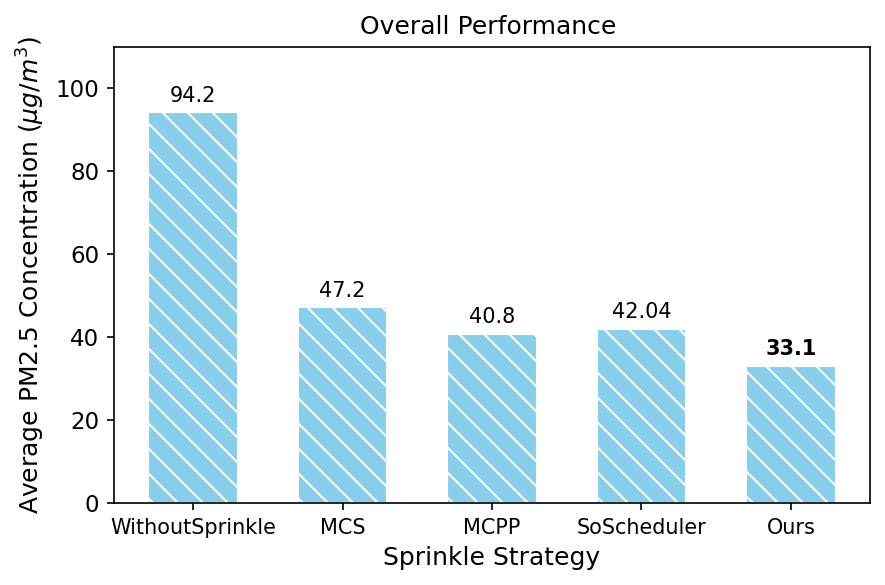

In [4]:
# 加一张图，只画颗粒物浓度
import matplotlib.pyplot as plt
import numpy as np

# Data
# models = ['WithoutSprinkle','MCS', 'MCPP', 'SoScheduler','TRACT',  'Ours']
# Average_Concentration = [94.2, 47.2, 40.8, 42.04,34.6,  33.1]

models = ['WithoutSprinkle','MCS', 'MCPP', 'SoScheduler',  'Ours']
Average_Concentration = [94.2, 47.2, 40.8, 42.04,  33.1]

x = np.arange(len(models))  
width = 0.6

fig, ax = plt.subplots(figsize =(6,4),dpi=150)
pm25_hatch = '//'
pm10_hatch = '\\\\'
edge_color = 'white'

for i in range(len(models)):
    ax.bar(x[i] + width/2, Average_Concentration[i], width, label='PM2.5 Average Concentration (μg/m³)' if i == 0 else "",
           color='skyblue', hatch=pm10_hatch, edgecolor=edge_color)

ax.set_ylabel('Average PM2.5 Concentration ($\mu{g}/m^3$)', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.set_xlabel('Sprinkle Strategy', fontsize=12)
ax.set_title('Overall Performance ')
ax.set_xticks(x+width/2)
ax.set_ylim([0, 110])
ax.set_xticklabels(models)

# 去掉标题
# ax.set_title('')

# 将图例放置在上方
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

def autolabel(values, offset):
    for i, value in enumerate(values):
        fontweight = 'bold' if models[i] == 'Ours' else 'normal'
        ax.annotate('{}'.format(value),
                    xy=(x[i] + offset, value),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight=fontweight)

autolabel(Average_Concentration, width/2)

fig.tight_layout()
filename = './outputs/png/Overall_SchedulingPerformance1.png'
plt.savefig(filename,bbox_inches = 'tight')


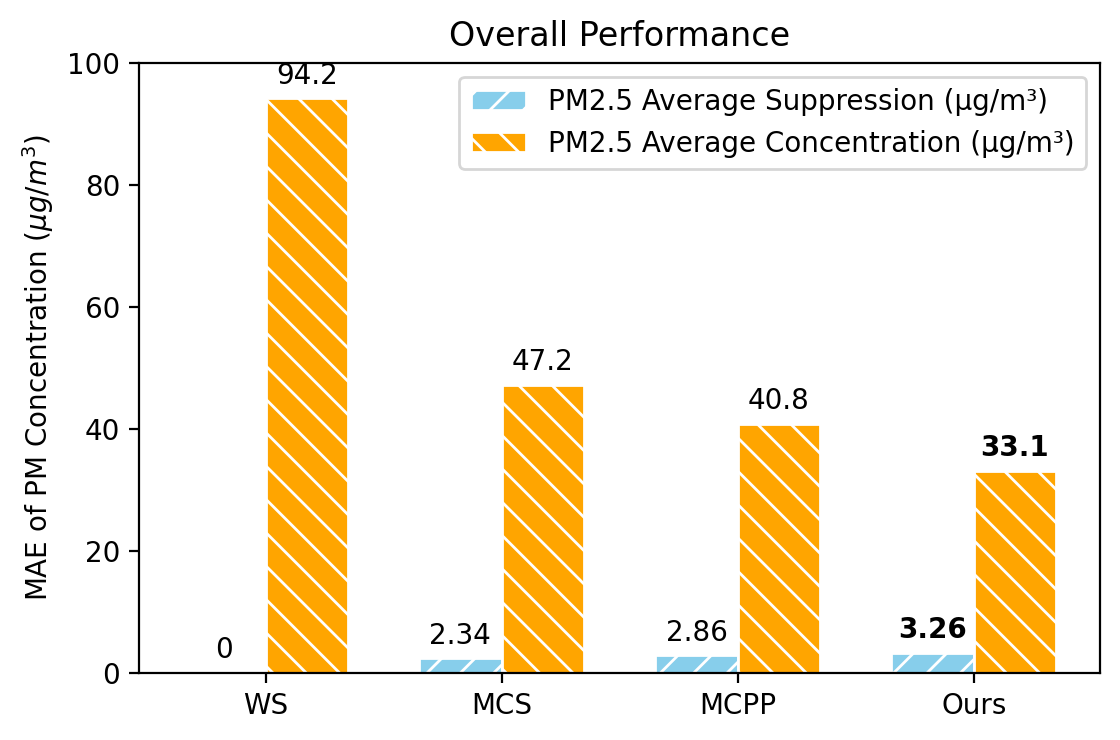

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['WS', 'MCS', 'MCPP', 'Ours']
Average_Suppression = [0, 2.34, 2.86, 3.26]
Average_Concentration = [94.2, 47.2, 40.8, 33.1]

x = np.arange(len(models))  
width = 0.35  

fig, ax = plt.subplots(figsize=(5.7, 3.8), dpi=200)
pm25_hatch = '//'
pm10_hatch = '\\\\'
edge_color = 'white'

for i in range(len(models)):
    ax.bar(x[i] - width/2, Average_Suppression[i], width, label='PM2.5 Average Suppression (μg/m³)' if i == 0 else "",
           color='skyblue', hatch=pm25_hatch, edgecolor=edge_color)
    ax.bar(x[i] + width/2, Average_Concentration[i], width, label='PM2.5 Average Concentration (μg/m³)' if i == 0 else "",
           color='orange', hatch=pm10_hatch, edgecolor=edge_color)

ax.set_ylabel('MAE of PM Concentration ($\mu{g}/m^3$)')
ax.set_title('Overall Performance')
ax.set_xticks(x)
ax.set_ylim([0, 100])
ax.set_xticklabels(models)
ax.legend()

def autolabel(values, offset):
    for i, value in enumerate(values):
        fontweight = 'bold' if models[i] == 'Ours' else 'normal'
        ax.annotate('{}'.format(value),
                    xy=(x[i] + offset, value),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight=fontweight)

autolabel(Average_Suppression, -width/2)
autolabel(Average_Concentration, width/2)

fig.tight_layout()

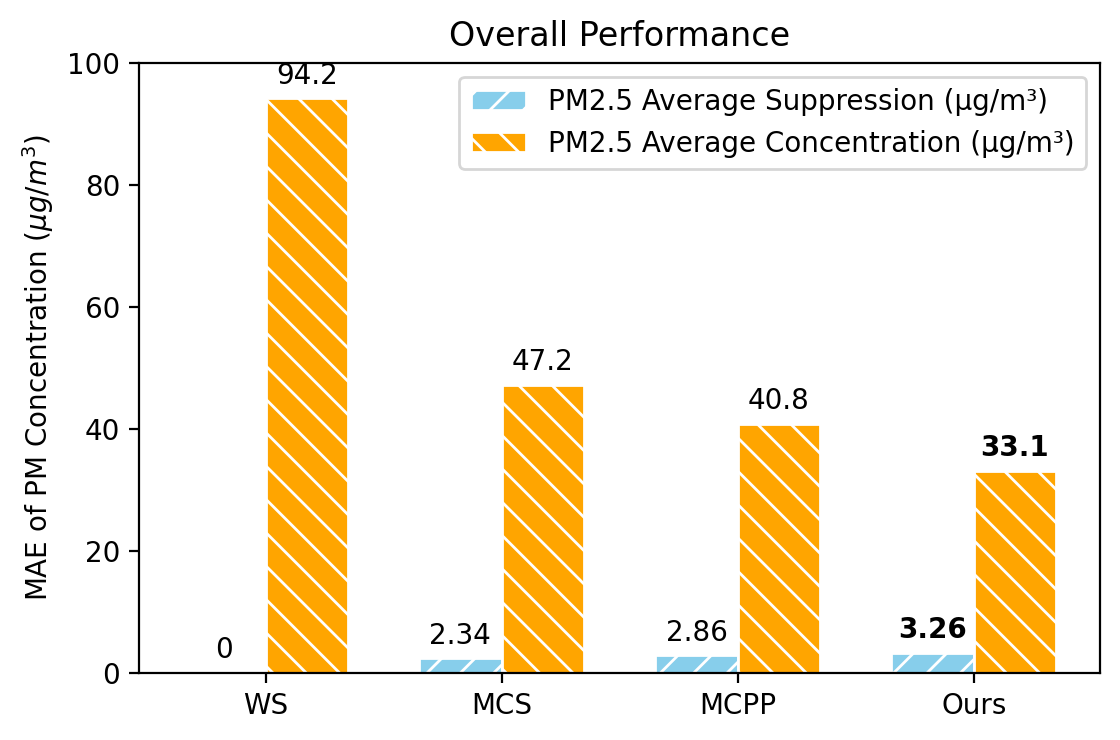

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['WS', 'MCS', 'MCPP', 'Ours']
Average_Suppression = [0, 2.34, 2.86, 3.26]
Average_Concentration = [94.2, 47.2, 40.8, 33.1]

x = np.arange(len(models))  
width = 0.35  

fig, ax = plt.subplots(figsize=(5.7, 3.8), dpi=200)
pm25_hatch = '//'
pm10_hatch = '\\\\'
edge_color = 'white'

for i in range(len(models)):
    ax.bar(x[i] - width/2, Average_Suppression[i], width, label='PM2.5 Average Suppression (μg/m³)' if i == 0 else "",
           color='skyblue', hatch=pm25_hatch, edgecolor=edge_color)
    ax.bar(x[i] + width/2, Average_Concentration[i], width, label='PM2.5 Average Concentration (μg/m³)' if i == 0 else "",
           color='orange', hatch=pm10_hatch, edgecolor=edge_color)

ax.set_ylabel('MAE of PM Concentration ($\mu{g}/m^3$)')
ax.set_title('Overall Performance')
ax.set_xticks(x)
ax.set_ylim([0, 100])
ax.set_xticklabels(models)
ax.legend()

def autolabel(values, offset):
    for i, value in enumerate(values):
        fontweight = 'bold' if models[i] == 'Ours' else 'normal'
        ax.annotate('{}'.format(value),
                    xy=(x[i] + offset, value),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight=fontweight)

autolabel(Average_Suppression, -width/2)
autolabel(Average_Concentration, width/2)

fig.tight_layout()

# plt.savefig("Overall_Performance.png", bbox_inches='tight')

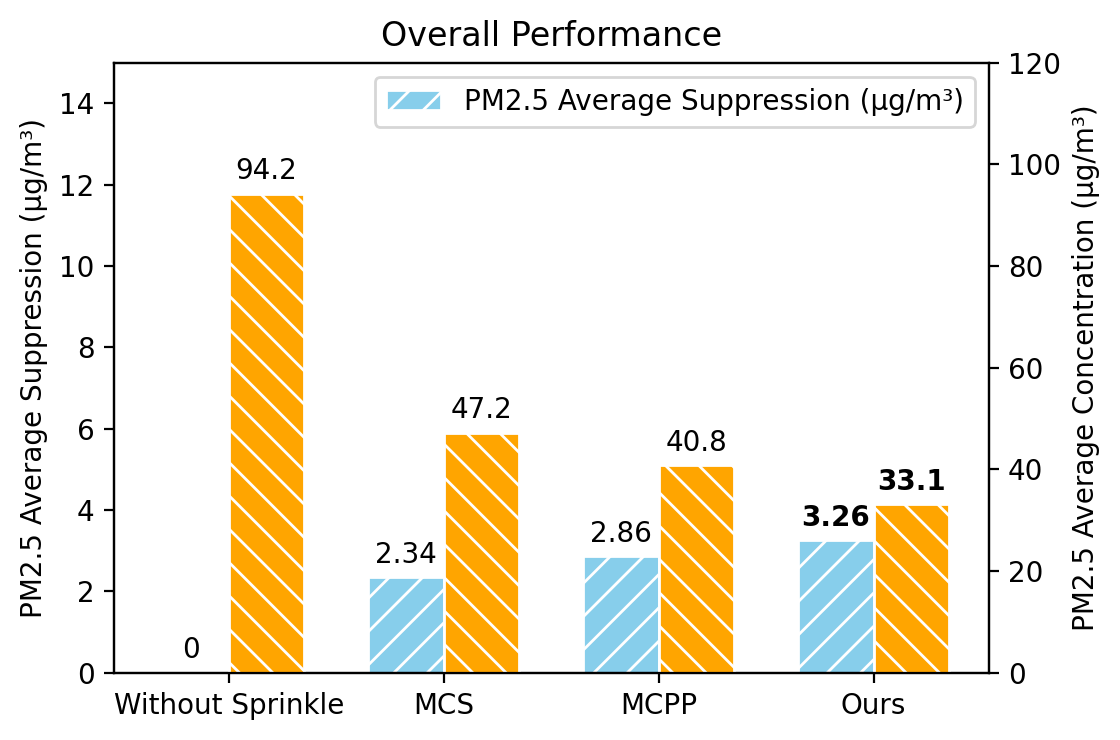

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Without Sprinkle', 'MCS', 'MCPP', 'Ours']
Average_Suppression = [0, 2.34, 2.86, 3.26]
Average_Concentration = [94.2, 47.2, 40.8, 33.1]

x = np.arange(len(models))  
width = 0.35  

fig, ax1 = plt.subplots(figsize=(5.7, 3.8), dpi=200)
ax2 = ax1.twinx()

pm25_hatch = '//'
pm10_hatch = '\\\\'
edge_color = 'white'

ax1.bar(x - width/2, Average_Suppression, width, label='PM2.5 Average Suppression (μg/m³)',
        color='skyblue', hatch=pm25_hatch, edgecolor=edge_color)
ax2.bar(x + width/2, Average_Concentration, width, label='PM2.5 Average Concentration (μg/m³)',
        color='orange', hatch=pm10_hatch, edgecolor=edge_color)

ax1.set_ylabel('PM2.5 Average Suppression (μg/m³)')
ax2.set_ylabel('PM2.5 Average Concentration (μg/m³)')
ax1.set_title('Overall Performance')
ax1.set_xticks(x)
ax1.set_ylim([0, 15])
ax2.set_ylim([0, 120])
ax1.set_xticklabels(models)
# ax1.legend(loc='upper left')
ax1.legend(loc='upper right')
# Move the legends to the top right corner and arrange them vertically

def autolabel(ax, values, offset):
    for i, value in enumerate(values):
        fontweight = 'bold' if models[i] == 'Ours' else 'normal'
        ax.annotate('{}'.format(value),
                    xy=(x[i] + offset, value),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight=fontweight)

autolabel(ax1, Average_Suppression, -width/2)
autolabel(ax2, Average_Concentration, width/2)

fig.tight_layout()
plt.savefig("./outputs/png/Overall_SchedulingPerformance1.png", bbox_inches='tight')